In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.set_default_dtype(torch.float64)

In [26]:
# Physical Parameters
E = 1.5e7     # kN/m2
NU = 1/6   
R = 10.0       # m
L = 20.0
h = 0.12    # m

gamma_c = 24
gamma_w = 10
p_x = -gamma_c * h

Cm = (E * h) / (1 - NU**2)
Cb = (E * h**3) / (12 * (1 - NU**2))

beta = (3 * (1 - NU**2) / (R**2 * h**2))**0.25
lamb = np.pi / beta
alpha = beta * L

# Hyperparameters
epochs = 5000
lr = 0.001
num_interior = 50
num_boundary = 100


In [27]:
# Non-dimensionalization
# w0 = (gamma_w * L * R**2) / (E * h)
# u0 = (abs(p_x) * L**2) / (2*Cm)
w0 = (gamma_w * L * R**2) / (Cm) 
u0 = (abs(p_x) * L**2) / (Cm)

Pi_0_ex = Cm * (u0 / L)**2
Pi_0_et = Cm * (w0 / R)**2
Pi_0_kx = Cb * (w0 / L**2)**2
print('Pi_0_ex ', Pi_0_ex)
print('Pi_0_et ', Pi_0_et)
print('Pi_0_kx ', Pi_0_kx)
Pi_0 = max(Pi_0_ex, Pi_0_et, Pi_0_kx)

# Some arrays
previous_loss = float('inf')
loss_history = []


Pi_0_ex  0.0017919999999999995
Pi_0_et  2.1604938271604945
Pi_0_kx  1.62037037037037e-06


1. Radial Deflection Scale ($w_0$)
The radial deflection $w$ is primarily driven by the water pushing outward against the walls. We can estimate the maximum deflection using basic Membrane Hoop Stress theory.
- Maximum Water Pressure:
The water pressure increases with depth. The maximum pressure is at the bottom of the tank ($x=0$), where the depth is $L$:$$P_{max} = \gamma_w \cdot L$$
- Maximum Hoop Force ($N_\theta$): 
In a cylinder, internal pressure creates a circumferential (hoop) force.$$N_\theta = P_{max} \cdot R = (\gamma_w \cdot L) \cdot R$$
- Hoop Strain ($\epsilon_\theta$): 
Hooke's Law relates force to strain via the stiffness of the wall ($C_m$).$$\epsilon_\theta = \frac{N_\theta}{C_m} = \frac{\gamma_w \cdot L \cdot R}{C_m}$$
- Kinematic Deflection ($w$): 
In a cylinder, the hoop strain is strictly defined as the radial expansion divided by the radius ($\epsilon_\theta = w / R$). Rearranging this gives us the maximum radial expansion:$$w_{max} = \epsilon_\theta \cdot R = \left( \frac{\gamma_w \cdot L \cdot R}{C_m} \right) \cdot R$$
$$\mathbf{w_0 = \frac{\gamma_w \cdot L \cdot R^2}{C_m}}$$

2. Axial Displacement Scale ($u_0$)
The axial displacement $u$ is driven entirely by the tank compressing downwards under its own heavy concrete weight. We can estimate this by treating the tank as a 1D Bar in Axial Compression.
- Axial Force Profile ($n_x$): 
The self-weight load is $p_x$ (N/m²). The total downward force accumulated at any height $x$ is the weight of the concrete above it:$$n_x(x) = p_x \cdot (L - x)$$
- Axial Strain ($e_x$): 
Using the membrane stiffness $C_m$, the strain at any height is:$$\frac{du}{dx} = \frac{n_x(x)}{C_m} = \frac{p_x \cdot (L - x)}{C_m}$$
- Total Displacement ($u$): 
To find the maximum displacement (which occurs at the free top edge, $x=L$), we integrate the strain from the rigidly clamped base ($x=0$) to the top:$$u_{max} = \int_0^L \frac{p_x \cdot (L - x)}{C_m} dx$$
$$u_{max} = \frac{p_x}{C_m} \left[ Lx - \frac{x^2}{2} \right]_0^L = \frac{p_x}{C_m} \left( L^2 - \frac{L^2}{2} \right)$$
$$u_{max} = \frac{p_x \cdot L^2}{2 \cdot C_m}$$
Taking the absolute value to ensure our scaling factor is positive gives:
$$\mathbf{u_0 = \frac{|p_x| \cdot L^2}{2 \cdot C_m}}$$

In [28]:
def grad(f, v):
    return torch.autograd.grad(f, v, grad_outputs=torch.ones_like(f), create_graph=True)[0]

In [29]:
# 1. Neural Network Architecture
class MembraneBendingCylindricalPINN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, output_size)
        )
    
        self.net_u = nn.Sequential(
            nn.Linear(1, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
        
        # Network for Radial Deflection (w)
        self.net_w = nn.Sequential(
            nn.Linear(1, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, 1)
            )
    
    def forward(self, x):
        # output = self.network(x)
        # u_bar = x * output[:, 0:1]
        # w_bar = x**2 * output[:, 1:2]
        # u = u_bar * u0
        # w = w_bar * w0

        # Split/Decouple into 2 independent networks for u and w
        out_u = self.net_u(x)
        out_w = self.net_w(x)
        u_bar = x * out_u
        w_bar = x**2 * out_w
        u = u_bar * u0
        w = w_bar * w0
        return u , w

In [30]:
# 2. Potential Energy and BC Loss Functions
def membrane_bending(model, x_phys):
    # Get coordinates and Enable gradient tracking
    x_phys.requires_grad_(True)
    x_bar = x_phys/L
    
    # Forward pass
    u, w = model(x_bar)
    
    # Gradients
    u_prime = grad(u, x_phys)
    w_prime = grad(w, x_phys)
    w_prime2 = grad(w_prime, x_phys)
        
    # Kinematic Equations
    e_x = u_prime
    e_t = w / R
    k_x = -w_prime2

    # Constitutive Equations
    n_x = Cm * (e_x + NU*e_t)
    n_t = Cm * (e_t + NU*e_x)
    m_x = Cb * k_x
    
    # Internal Energy
    U_mem = 0.5 * (n_x*e_x + n_t*e_t)
    U_ben = 0.5 * (m_x*k_x)

    # External Work
    p_n = gamma_w * (L - x_phys)
    W_density = p_x*u + p_n*w

    # Total
    # MONTE CARLO APPROXIMATION
    # loss_energy = torch.mean(U_mem + U_ben - W_density) / Pi_0
    
    # EXACT TRAPEZOIDAL INTEGRATION
    density = (U_mem + U_ben - W_density) / Pi_0
    x_phys_sorted, indices = torch.sort(x_phys, dim=0)
    density_sorted = density[indices.squeeze()]
    dx = x_phys_sorted[1:] - x_phys_sorted[:-1]
    integrand = 0.5 * (density_sorted[1:] + density_sorted[:-1])
    loss_energy = torch.sum(integrand * dx) / L

    # BCs
    x_top = torch.tensor([[L]], dtype=torch.float64, device=x_phys.device, requires_grad=True)
    u_top, w_top = model(x_top / L)
    du_dx_top = grad(u_top, x_top)
    # dw_dx_top = grad(w_top, x_top)
    # d2w_dx_top = grad(dw_dx_top, x_top)
    # d3w_dx_top = grad(d2w_dx_top, x_top)
    ex_top = du_dx_top
    et_top = w_top / R
    # kx_top = - d2w_dx_top
    nx_top = ex_top + NU * et_top
    # nt_top = et_top + NU * ex_top
    # n_0 = w0 / L
    n_0 = abs(p_x) * L
    # m_0 = w0 / (L**2)
    # q_0 = w0 / (L**3)
    # loss_nt_top = ((nt_top / n_0)**2).squeeze()
    loss_nx_top = ((nx_top / n_0)**2).squeeze()
    # loss_mx_top = ((kx_top / m_0)**2).squeeze()
    # loss_qx_top = ((d3w_dx_top / q_0)**2).squeeze()

    # Choose penalty of loss = 1.0
    # increasing this decreases the effect of loss_energy
    return loss_energy + 1.0*(loss_nx_top) 


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MembraneBendingCylindricalPINN(1, 2, 64).to(device)

# Training Loop
print("Starting training...")

# Generate Points
x_col = torch.linspace(0, L, 4000, device=device).unsqueeze(1)
# x_col = torch.cat([
#     torch.linspace(0, L, 1500, device=device).unsqueeze(1),
#     torch.linspace(0, 0.1*L, 400, device=device).unsqueeze(1)
# ], dim=0)

# --- PHASE 1: ADAM OPTIMIZER ---
optimizer_adam = optim.Adam(model.parameters(), lr=2e-3)
print("Phase 1: Adam Optimizer (Finding the neighborhood)")
for epoch in range(epochs+1):
    optimizer_adam.zero_grad()

    # Physics loss (Energy minimization)
    total_loss = membrane_bending(model, x_col)

    total_loss.backward()
    optimizer_adam.step()
    
    current_loss = total_loss.item()
    loss_history.append(current_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Energy: {current_loss}")
    
    # Convergence Check
    if epoch > 0:
        relative_error = abs(previous_loss - current_loss) / abs(current_loss + 1e-15)
        if relative_error < 1e-20:
            print(f"Convergent at epoch {epoch}. Relative error: {relative_error}")
            break
    
    previous_loss = current_loss    

# --- PHASE 2: L-BFGS OPTIMIZER ---
print("\nPhase 2: L-BFGS Optimizer (High-precision polishing)")
# L-BFGS requires a static set of points during its line search closure
# x_static = torch.cat([
#     torch.linspace(0, L, 4000, device=device).unsqueeze(1),
#     torch.tensor([[0.0], [L]], dtype=torch.float64, device=device)
# ], dim=0)
x_static = torch.linspace(0, L, 6000, device=device).unsqueeze(1)

optimizer_lbfgs = optim.LBFGS(model.parameters(), 
                                max_iter=3000,
                                tolerance_grad=1e-7, 
                                tolerance_change=1e-9, 
                                history_size=100,
                                line_search_fn="strong_wolfe")

def closure():
    optimizer_lbfgs.zero_grad()
    loss = membrane_bending(model, x_static)
    loss.backward()
    return loss
    
optimizer_lbfgs.step(closure)

# Print final loss after L-BFGS
final_loss = membrane_bending(model, x_static)
print(f"  Final L-BFGS Energy Loss: {final_loss.item():.6e}\n")

Starting training...
Phase 1: Adam Optimizer (Finding the neighborhood)
Epoch 0 | Energy: 0.001230533435077945
Epoch 500 | Energy: -0.12277810060137608
Epoch 1000 | Energy: -0.1284336783861897
Epoch 1500 | Energy: -0.1314866770435649
Epoch 2000 | Energy: -0.13360625882238228
Epoch 2500 | Energy: -0.13516370055030205
Epoch 3000 | Energy: -0.1363987071988471
Epoch 3500 | Energy: -0.1375340907439579
Epoch 4000 | Energy: -0.1383999354239907
Epoch 4500 | Energy: -0.13920878141392296
Epoch 5000 | Energy: -0.13991081172029926

Phase 2: L-BFGS Optimizer (High-precision polishing)
  Final L-BFGS Energy Loss: -1.523461e-01



In [40]:
def get_analytical_solutions(x):
    # Particular (Membrane) Solution
    wp_0 = (R / (E * h)) * (gamma_w * R * L + NU * gamma_c * h * L)
    wp_prime = - (R / (E * h)) * (gamma_w * R + NU * gamma_c * h)
    wp_x = (R / (E * h)) * (gamma_w * R * (L - x) + NU * gamma_c * h * (L - x))
    
    # Homogeneous (Bending Boundary Layer) Solution
    C1 = -wp_0
    C2 = -wp_0 - (wp_prime / beta)
    # print('C1 ', C1)
    # print('C2 ', C2)
    wh_x = np.exp(-beta * x) * (C1 * np.cos(beta * x) + C2 * np.sin(beta * x))
    wh_xx = 2 * beta**2 * np.exp(-beta * x) * (C1 * np.sin(beta * x) - C2 * np.cos(beta * x))
    
    # Combined Exact Deflection
    u_exact = (-gamma_c*h - NU*gamma_w*R)*(L*x - 0.5*x**2) / (E*h)
    w_exact = wp_x + wh_x
        
    nx_exact = -gamma_c * h * (L - x)
    nt_exact = (E*h/R) * w_exact + NU * nx_exact
    mx_exact = -Cb * wh_xx
    mt_exact = NU * mx_exact

    ex_exact = (nx_exact - NU * nt_exact) / (E*h)
    et_exact = w_exact / R

    kx_exact = -wh_xx
    
    return u_exact, w_exact, nx_exact, nt_exact, mx_exact, mt_exact, ex_exact, et_exact, kx_exact

In [41]:
device = next(model.parameters()).device
model.eval() # Set to evaluation mode

# test_x = [0.0, lamb, 2*lamb, L/2, L] 
test_x = [0.0, L] 

print(f"\n==========================================================================================")
print(f"Results for Membrane-Bending State under Self-Weight and Hydrostatic Pressure")
print(f"==========================================================================================")
print(f"{'Height (x)':<12} | {'Quantity':<15} | {'PINN':<18} | {'Analytical':<18} | {'Error (%)'}")
print(f"------------------------------------------------------------------------------------------")

for x_val in test_x:
    x_t = torch.tensor([[x_val]], dtype=torch.float64, requires_grad=True)
    u, w = model(x_t / L)
    
    u_prime = grad(u, x_t)
    w_prime = grad(w, x_t)
    w_prime2 = grad(w_prime, x_t)

    u_num = u.item()
    w_num = w.item()
    
    # Numerical Forces
    ex_num = float(u_prime.item())
    et_num = float(w.item() / R)
    kx_num = float((-w_prime2).item())

    nx_num = Cm * (ex_num + NU * et_num)
    nt_num = Cm * (et_num + NU * ex_num)
    mx_num = Cb * kx_num
    mt_num = NU * Cb * kx_num
    
    # Analytical Forces
    u_exact, w_exact, nx_exact, nt_exact, mx_exact, mt_exact, ex_exact, et_exact, kx_exact = get_analytical_solutions(x_val)

    # Errors
    err_nx = abs((nx_num - nx_exact)/nx_exact)*100 if abs(nx_exact)>1e-7 else 0
    err_nt = abs((nt_num - nt_exact)/nt_exact)*100 if abs(nt_exact)>1e-7 else 0
    err_mx = abs((mx_num - mx_exact)/mx_exact)*100 if abs(mx_exact)>1e-7 else 0
    err_mt = abs((mt_num - mt_exact)/mt_exact)*100 if abs(mt_exact)>1e-7 else 0
    err_ex = abs((ex_num - ex_exact)/ex_exact)*100 if abs(ex_exact)>1e-7 else 0
    err_et = abs((et_num - et_exact)/et_exact)*100 if abs(et_exact)>1e-7 else 0
    err_kx = abs((kx_num - kx_exact)/kx_exact)*100 if abs(kx_exact)>1e-7 else 0
    
    print(f"{x_val:<12.2f} | {'e_x ':<15} | {ex_num:<18.4e} | {ex_exact:<18.4e} | {err_ex:.4f}%")
    print(f"{'':<12} | {'e_theta ':<15} | {et_num:<18.4e} | {et_exact:<18.4e} | {err_et:.4f}%")
    print(f"{'':<12} | {'k_x ':<15} | {kx_num:<18.4e} | {kx_exact:<18.4e} | {err_kx:.4f}%")
    print(f"{'':<12} | {'n_x ':<15} | {nx_num:<18.4e} | {nx_exact:<18.4e} | {err_nx:.4f}%")
    print(f"{'':<12} | {'n_theta ':<15} | {nt_num:<18.4e} | {nt_exact:<18.4e} | {err_nt:.4f}%")
    print(f"{'':<12} | {'m_x ':<15} | {mx_num:<18.4e} | {mx_exact:<18.4e} | {err_mx:.4f}%")
    print(f"{'':<12} | {'m_t ':<15} | {mt_num:<18.4e} | {mt_exact:<18.4e} | {err_mt:.4f}%")
    print(f"------------------------------------------------------------------------------------------")


Results for Membrane-Bending State under Self-Weight and Hydrostatic Pressure
Height (x)   | Quantity        | PINN               | Analytical         | Error (%)
------------------------------------------------------------------------------------------
0.00         | e_x             | -3.4703e-05        | -3.1111e-05        | 11.5453%
             | e_theta         | 0.0000e+00         | 0.0000e+00         | 0.0000%
             | k_x             | -3.0476e-02        | -3.0446e-02        | 0.0967%
             | n_x             | -6.4250e+01        | -5.7600e+01        | 11.5453%
             | n_theta         | -1.0708e+01        | -9.6000e+00        | 11.5453%
             | m_x             | -6.7708e+01        | -6.7643e+01        | 0.0967%
             | m_t             | -1.1285e+01        | -1.1274e+01        | 0.0967%
------------------------------------------------------------------------------------------
20.00        | e_x             | -1.1018e-06        | -5.0351e-15     

In [34]:
# # 4. Visualization
# scale_factor=1

# device = next(model.parameters()).device
# model.eval()

# x_vec = np.linspace(0, L, num_interior)
# theta_vec = np.linspace(theta_0, theta_L, num_interior)
# X, THETA = np.meshgrid(x_vec, theta_vec)

# phi_t = torch.tensor(X.flatten().reshape(-1, 1), dtype=torch.float32, device=device)
# theta_t = torch.tensor(THETA.flatten().reshape(-1, 1), dtype=torch.float32, device=device)

# with torch.no_grad():
#     u_pred, w_pred = model(phi_t)
#     u_pred = u_pred.cpu().numpy().reshape(num_interior, num_interior)
#     w_pred = w_pred.cpu().numpy().reshape(num_interior, num_interior)

# X = R * np.sin(PHI) * np.cos(THETA)
# Y = R * np.sin(PHI) * np.sin(THETA)
# Z = R * np.cos(PHI)
    
# X_def = (R + w_pred * scale_factor) * np.sin(PHI) * np.cos(THETA)
# Y_def = (R + w_pred * scale_factor) * np.sin(PHI) * np.sin(THETA)
# Z_def = (R + w_pred * scale_factor) * np.cos(PHI)


# fig = plt.figure(figsize=(18, 6))

# ax1 = fig.add_subplot(131, projection='3d')
# surf = ax1.plot_surface(X_def, Y_def, Z_def, facecolors=plt.cm.viridis(w_pred / np.max(w_pred)), 
#                         edgecolor='none', alpha=0.9)
# ax1.set_title(f"Deformed Shape (Scale: {scale_factor}x)")

# ax2 = fig.add_subplot(132)
# cp2 = ax2.contourf(PHI, THETA, w_pred, cmap='coolwarm', levels=20)
# fig.colorbar(cp2, ax=ax2).set_label('Radial Deflection w (m)')
# ax2.set_title("Deflection w(phi, theta)")
# ax2.set_xlabel("Meridional Angle (phi)")

# ax3 = fig.add_subplot(133)
# cp3 = ax3.contourf(PHI, THETA, u_pred, cmap='plasma', levels=20)
# fig.colorbar(cp3, ax=ax3).set_label('Meridional Disp. u (m)')
# ax3.set_title("Tangential Displacement u(phi, theta)")
# ax3.set_xlabel("Meridional Angle (phi)")

# plt.tight_layout()
# plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


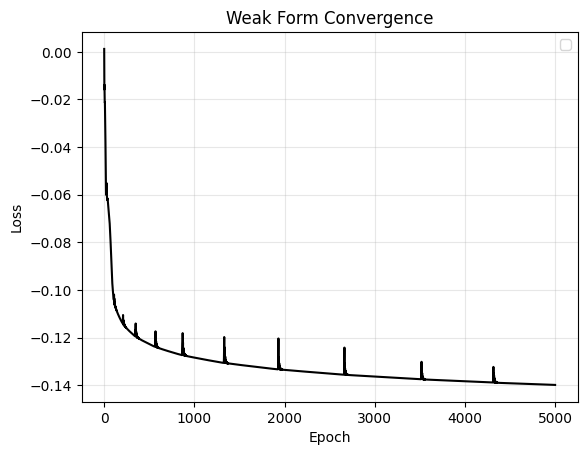

In [35]:
plt.plot(loss_history, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Weak Form Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()